In [161]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


##Dataset Overview

In [139]:
df = pd.read_csv("/content/drive/MyDrive/DSA/DATA SETS/House_Pricing.csv")

In [140]:
# info

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   ID                                         21613 non-null  int64  
 1   Date House was Sold                        21613 non-null  object 
 2   Sale Price                                 21609 non-null  float64
 3   No of Bedrooms                             21613 non-null  int64  
 4   No of Bathrooms                            21609 non-null  float64
 5   Flat Area (in Sqft)                        21604 non-null  float64
 6   Lot Area (in Sqft)                         21604 non-null  float64
 7   No of Floors                               21613 non-null  float64
 8   Waterfront View                            21613 non-null  object 
 9   No of Times Visited                        2124 non-null   object 
 10  Condition of the House

In [141]:
# describe - Statistical summary

df.describe()

,ID,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
count,2.161300e+04,2.160900e+04,21613.000000,21609.000000,21604.000000,2.160400e+04,21613.000000,21613.000000,21610.000000,21613.000000,21613.000000,21613.000000,21612.000000,21612.000000,21612.000000,21612.000000,21613.000000
mean,4.580302e+09,5.401984e+05,3.370842,2.114732,2079.931772,1.510776e+04,1.494309,7.623467,1788.344193,291.509045,46.994864,84.402258,98077.937766,47.560048,-122.213892,1986.538914,12768.455652
std,2.876566e+09,3.673890e+05,0.930062,0.770138,918.487597,4.142827e+04,0.539989,1.105439,827.982604,442.575043,29.373411,401.679240,53.505425,0.138565,0.140830,685.404255,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,1.000000,290.000000,0.000000,3.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1429.250000,5.040000e+03,1.000000,7.000000,1190.000000,0.000000,21.000000,0.000000,98033.000000,47.470975,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.617500e+03,1.500000,7.000000,1560.000000,0.000000,43.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068825e+04,2.000000,8.000000,2210.000000,560.000000,67.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,10.000000,9410.000000,4820.000000,118.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


##Duplicate Removal

In [142]:
# Row Duplicates

print("Duplicate rows:", df.duplicated().sum())

df = df.drop_duplicates()



Duplicate rows: 0


In [143]:
# Column duplicates

duplicate_cols = df.columns[df.T.duplicated()]
print("Duplicate columns:", duplicate_cols)

df = df.drop(columns=duplicate_cols)


Duplicate columns: Index([], dtype='object')


## Handling Missing Values

In [144]:
#  missing values in each column

print(df.isnull().sum())


ID                                               0
Date House was Sold                              0
Sale Price                                       4
No of Bedrooms                                   0
No of Bathrooms                                  4
Flat Area (in Sqft)                              9
Lot Area (in Sqft)                               9
No of Floors                                     0
Waterfront View                                  0
No of Times Visited                          19489
Condition of the House                           0
Overall Grade                                    0
Area of the House from Basement (in Sqft)        3
Basement Area (in Sqft)                          0
Age of House (in Years)                          0
Renovated Year                                   0
Zipcode                                          1
Latitude                                         1
Longitude                                        1
Living Area after Renovation (i

In [145]:
# Separate column types

num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns


In [146]:
# Handle Numerical Columns (Median)

# Select numerical columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Fill missing values with median
for col in num_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())



In [147]:
# Handle Categorical Columns (Mode)

# Select categorical columns
cat_cols = df.select_dtypes(include=['object']).columns

# Fill missing values with mode
for col in cat_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])



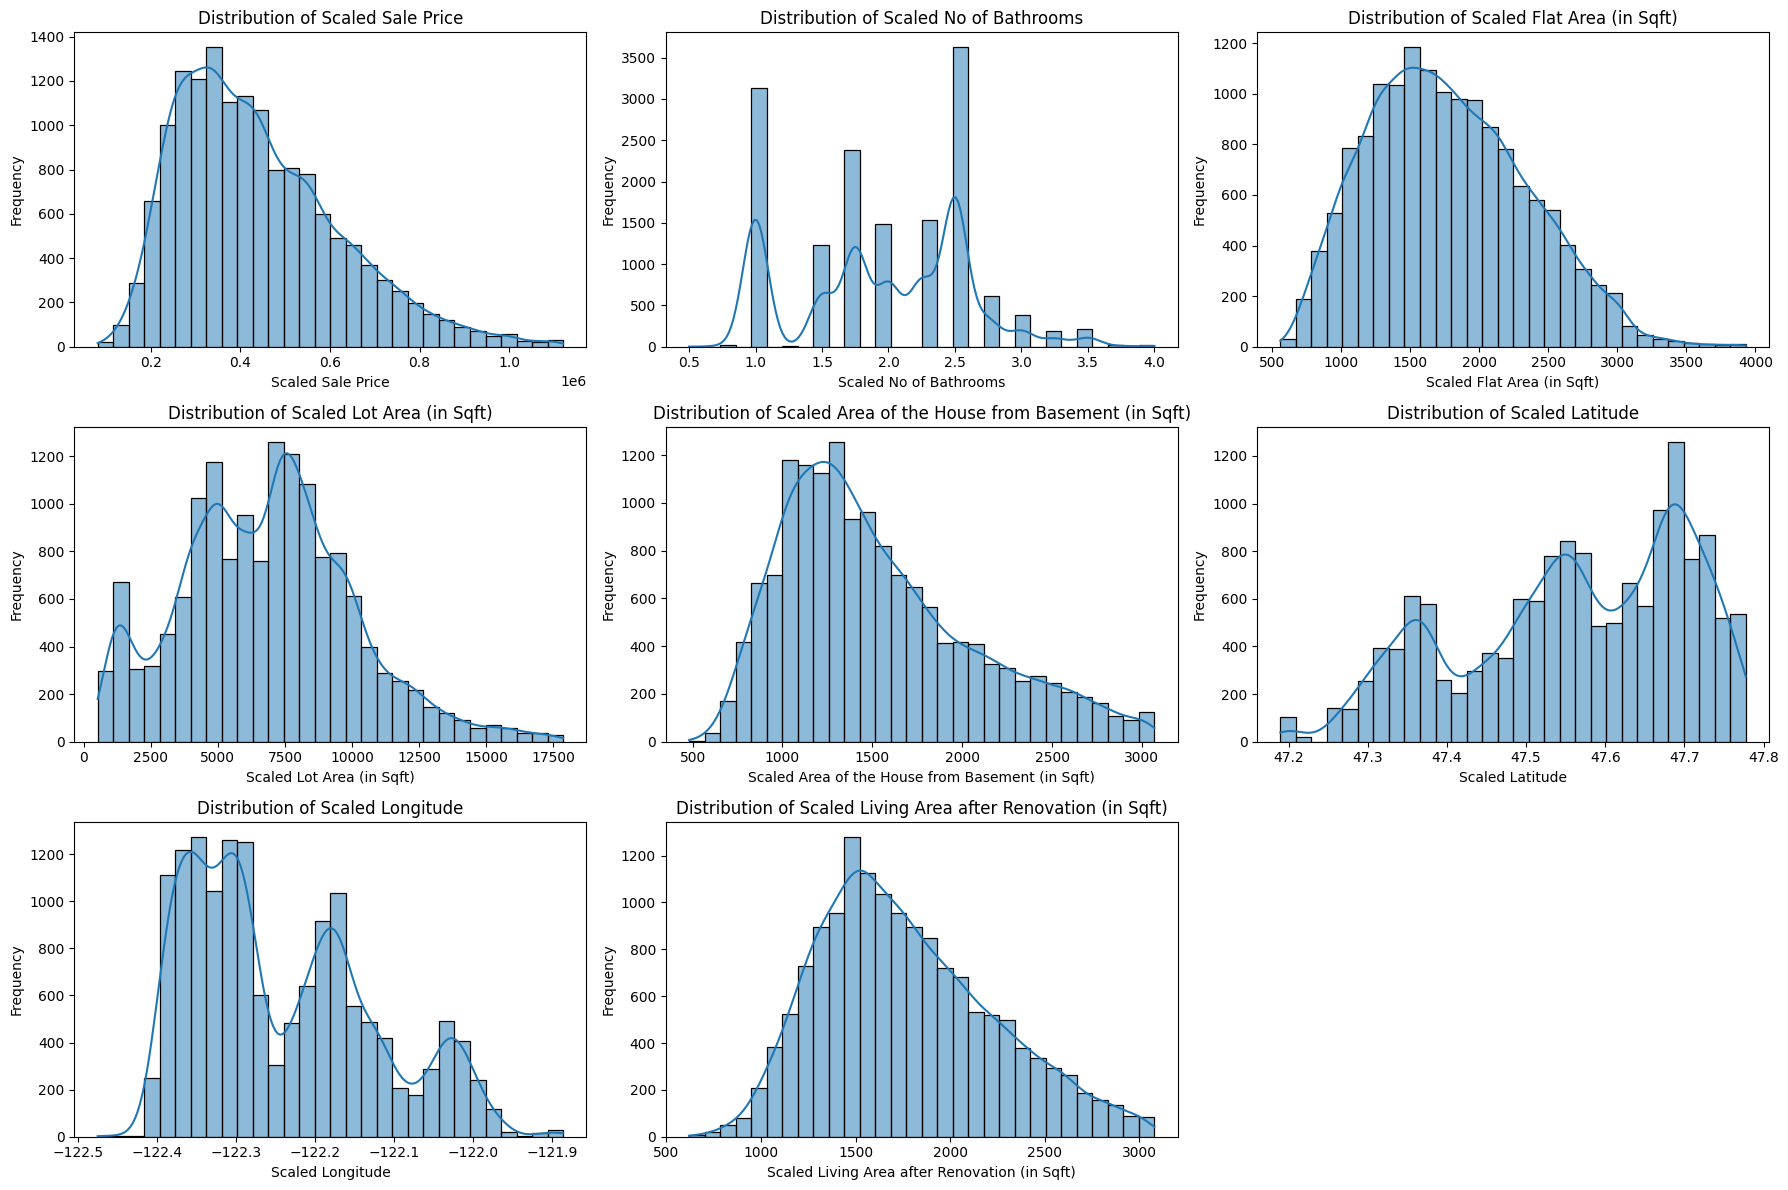

In [162]:
# Histogram (Distribution)


columns_to_plot = [
    'Sale Price',
    'No of Bathrooms',
    'Flat Area (in Sqft)',
    'Lot Area (in Sqft)',
    'Area of the House from Basement (in Sqft)',
    'Latitude',
    'Longitude',
    'Living Area after Renovation (in Sqft)'
]


plt.figure(figsize=(18, 12))
for i, col in enumerate(columns_to_plot):
    plt.subplot(3, 3, i + 1) # Using a 3x3 grid, adjust as needed
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f'Distribution of Scaled {col}')
    plt.xlabel(f'Scaled {col}')
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()


In [149]:
# Missing value treatment

# Missing values were identified using:

df.isnull().sum()


,0
ID,0
Date House was Sold,0
Sale Price,0
No of Bedrooms,0
No of Bathrooms,0
Flat Area (in Sqft),0
Lot Area (in Sqft),0
No of Floors,0
Waterfront View,0
No of Times Visited,0


In [150]:
print(df.columns)


Index(['ID', 'Date House was Sold', 'Sale Price', 'No of Bedrooms',
       'No of Bathrooms', 'Flat Area (in Sqft)', 'Lot Area (in Sqft)',
       'No of Floors', 'Waterfront View', 'No of Times Visited',
       'Condition of the House', 'Overall Grade',
       'Area of the House from Basement (in Sqft)', 'Basement Area (in Sqft)',
       'Age of House (in Years)', 'Renovated Year', 'Zipcode', 'Latitude',
       'Longitude', 'Living Area after Renovation (in Sqft)',
       'Lot Area after Renovation (in Sqft)'],
      dtype='object')


##Scaling Numerical Variables

In [151]:
#Separate Features and Target

X = df.drop('Sale Price', axis=1)
y = df['Sale Price']


In [152]:
#Identify Numerical Columns

num_cols = X.select_dtypes(include=['int64', 'float64']).columns

print("Numerical columns:\n", num_cols)


Numerical columns:
 Index(['ID', 'No of Bedrooms', 'No of Bathrooms', 'Flat Area (in Sqft)',
       'Lot Area (in Sqft)', 'No of Floors', 'Overall Grade',
       'Area of the House from Basement (in Sqft)', 'Basement Area (in Sqft)',
       'Age of House (in Years)', 'Renovated Year', 'Zipcode', 'Latitude',
       'Longitude', 'Living Area after Renovation (in Sqft)',
       'Lot Area after Renovation (in Sqft)'],
      dtype='object')


In [153]:
#Train-Test Split (Before Scaling)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [154]:
# Apply Scaling

# Convert to float first
X_train[num_cols] = X_train[num_cols].astype(float)
X_test[num_cols] = X_test[num_cols].astype(float)

#apply scaling

scaler = StandardScaler()

X_train.loc[:, num_cols] = scaler.fit_transform(X_train[num_cols])
X_test.loc[:, num_cols] = scaler.transform(X_test[num_cols])


In [155]:
#Min-Max Scaling

# Convert to float
X_train[num_cols] = X_train[num_cols].astype(float)
X_test[num_cols] = X_test[num_cols].astype(float)

# Apply scaling
scaler = StandardScaler()

X_train.loc[:, num_cols] = scaler.fit_transform(X_train[num_cols])
X_test.loc[:, num_cols] = scaler.transform(X_test[num_cols])


##Encoding Categorical Variables

In [156]:
#Identify Categorical Columns

cat_cols = df.select_dtypes(include=['object']).columns

print("Categorical columns:", cat_cols)


Categorical columns: Index(['Date House was Sold', 'Waterfront View', 'No of Times Visited',
       'Condition of the House'],
      dtype='object')


In [157]:
#One-Hot Encoding (for most columns)

df = pd.get_dummies(df, columns=cat_cols, drop_first=True)


##Outlier Removal

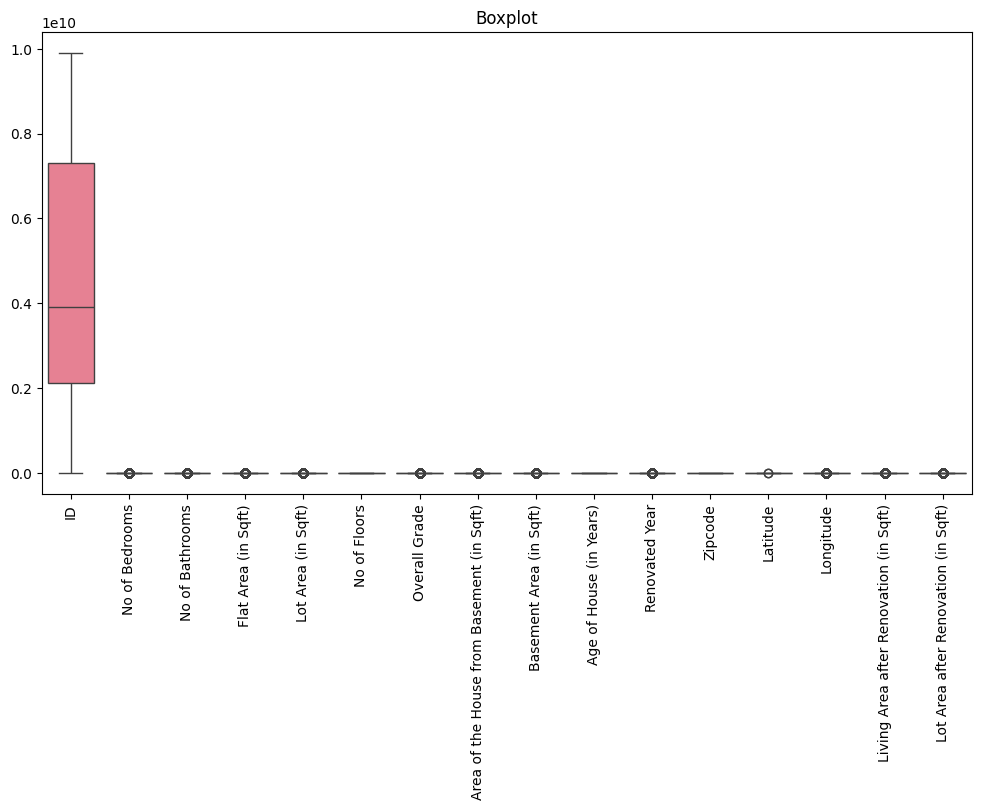

In [158]:
# Boxplot

plt.figure(figsize=(12,6))
sns.boxplot(data=df[num_cols])
plt.title('Boxplot')
plt.xticks(rotation=90)
plt.show()

In [159]:
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    initial_rows = df.shape[0]
    df_filtered = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    removed_rows = initial_rows - df_filtered.shape[0]
    if removed_rows > 0:
        print(f"Removed {removed_rows} outliers from '{column}'.")
    return df_filtered

# Re-identifying numerical columns as the DataFrame structure might have changed slightly with encoding.
# Exclude 'ID' and 'Zipcode' from outlier removal, as they are identifiers/categorical.
current_numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
columns_for_outlier_removal = [col for col in current_numerical_cols if col not in ['ID', 'Zipcode', 'Sale_Year', 'Sale_Month', 'Sale_Day_of_Week', 'Condition of the House']]

initial_shape = df.shape
print(f"Initial DataFrame shape: {initial_shape}")

for col in columns_for_outlier_removal:
    df = remove_outliers_iqr(df, col)

final_shape = df.shape
print(f"Final DataFrame shape after outlier removal: {final_shape}")
print(f"Total rows removed: {initial_shape[0] - final_shape[0]}")

display(df.head())

Initial DataFrame shape: (21613, 37)
Removed 1159 outliers from 'Sale Price'.
Removed 482 outliers from 'No of Bedrooms'.
Removed 67 outliers from 'No of Bathrooms'.
Removed 264 outliers from 'Flat Area (in Sqft)'.
Removed 2058 outliers from 'Lot Area (in Sqft)'.
Removed 661 outliers from 'Overall Grade'.
Removed 442 outliers from 'Area of the House from Basement (in Sqft)'.
Removed 234 outliers from 'Basement Area (in Sqft)'.
Removed 578 outliers from 'Renovated Year'.
Removed 344 outliers from 'Longitude'.
Removed 140 outliers from 'Living Area after Renovation (in Sqft)'.
Removed 322 outliers from 'Lot Area after Renovation (in Sqft)'.
Final DataFrame shape after outlier removal: (14862, 37)
Total rows removed: 6751


,ID,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),...,Date House was Sold_15 March 2016,Date House was Sold_15 May 2016,Waterfront View_Yes,No of Times Visited_Once,No of Times Visited_Thrice,No of Times Visited_Twice,Condition of the House_Excellent,Condition of the House_Fair,Condition of the House_Good,Condition of the House_Okay
0,7129300520,221900.0,3,1.00,1180.0,5650.0,1.0,7,1180.0,0,...,False,False,False,False,False,True,False,True,False,False
2,5631500400,180000.0,2,1.00,770.0,10000.0,1.0,6,770.0,0,...,False,False,False,False,False,True,False,True,False,False
3,2487200875,604000.0,4,3.00,1960.0,5000.0,1.0,7,1050.0,910,...,False,False,False,False,False,True,True,False,False,False
4,1954400510,510000.0,3,2.00,1680.0,8080.0,1.0,8,1680.0,0,...,False,False,False,False,False,True,False,True,False,False
6,1321400060,257500.0,3,2.25,1715.0,6819.0,2.0,7,1715.0,0,...,False,False,False,False,False,True,False,True,False,False


##Train-Test Split

In [160]:
# Define features (X) and target (y)
X = df.drop('Sale Price', axis=1)
y = df['Sale Price']

# Split the dataset into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Dataset split into training and testing sets.")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")


Dataset split into training and testing sets.
X_train shape: (11889, 36)
X_test shape: (2973, 36)
y_train shape: (11889,)
y_test shape: (2973,)
